In [24]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
from warnings import filterwarnings
filterwarnings("ignore")

In [3]:
df = pd.read_csv('/content/drive/MyDrive/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [4]:
df.shape

(2240, 28)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [6]:
df.describe()

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
print("The data is from ", df['Dt_Customer'].min() , " to ",df['Dt_Customer'].max())

The data is from  1/1/13  to  9/9/13


In [8]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

In [9]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [10]:
df = df.dropna()

In [11]:
df.duplicated().sum()

np.int64(0)

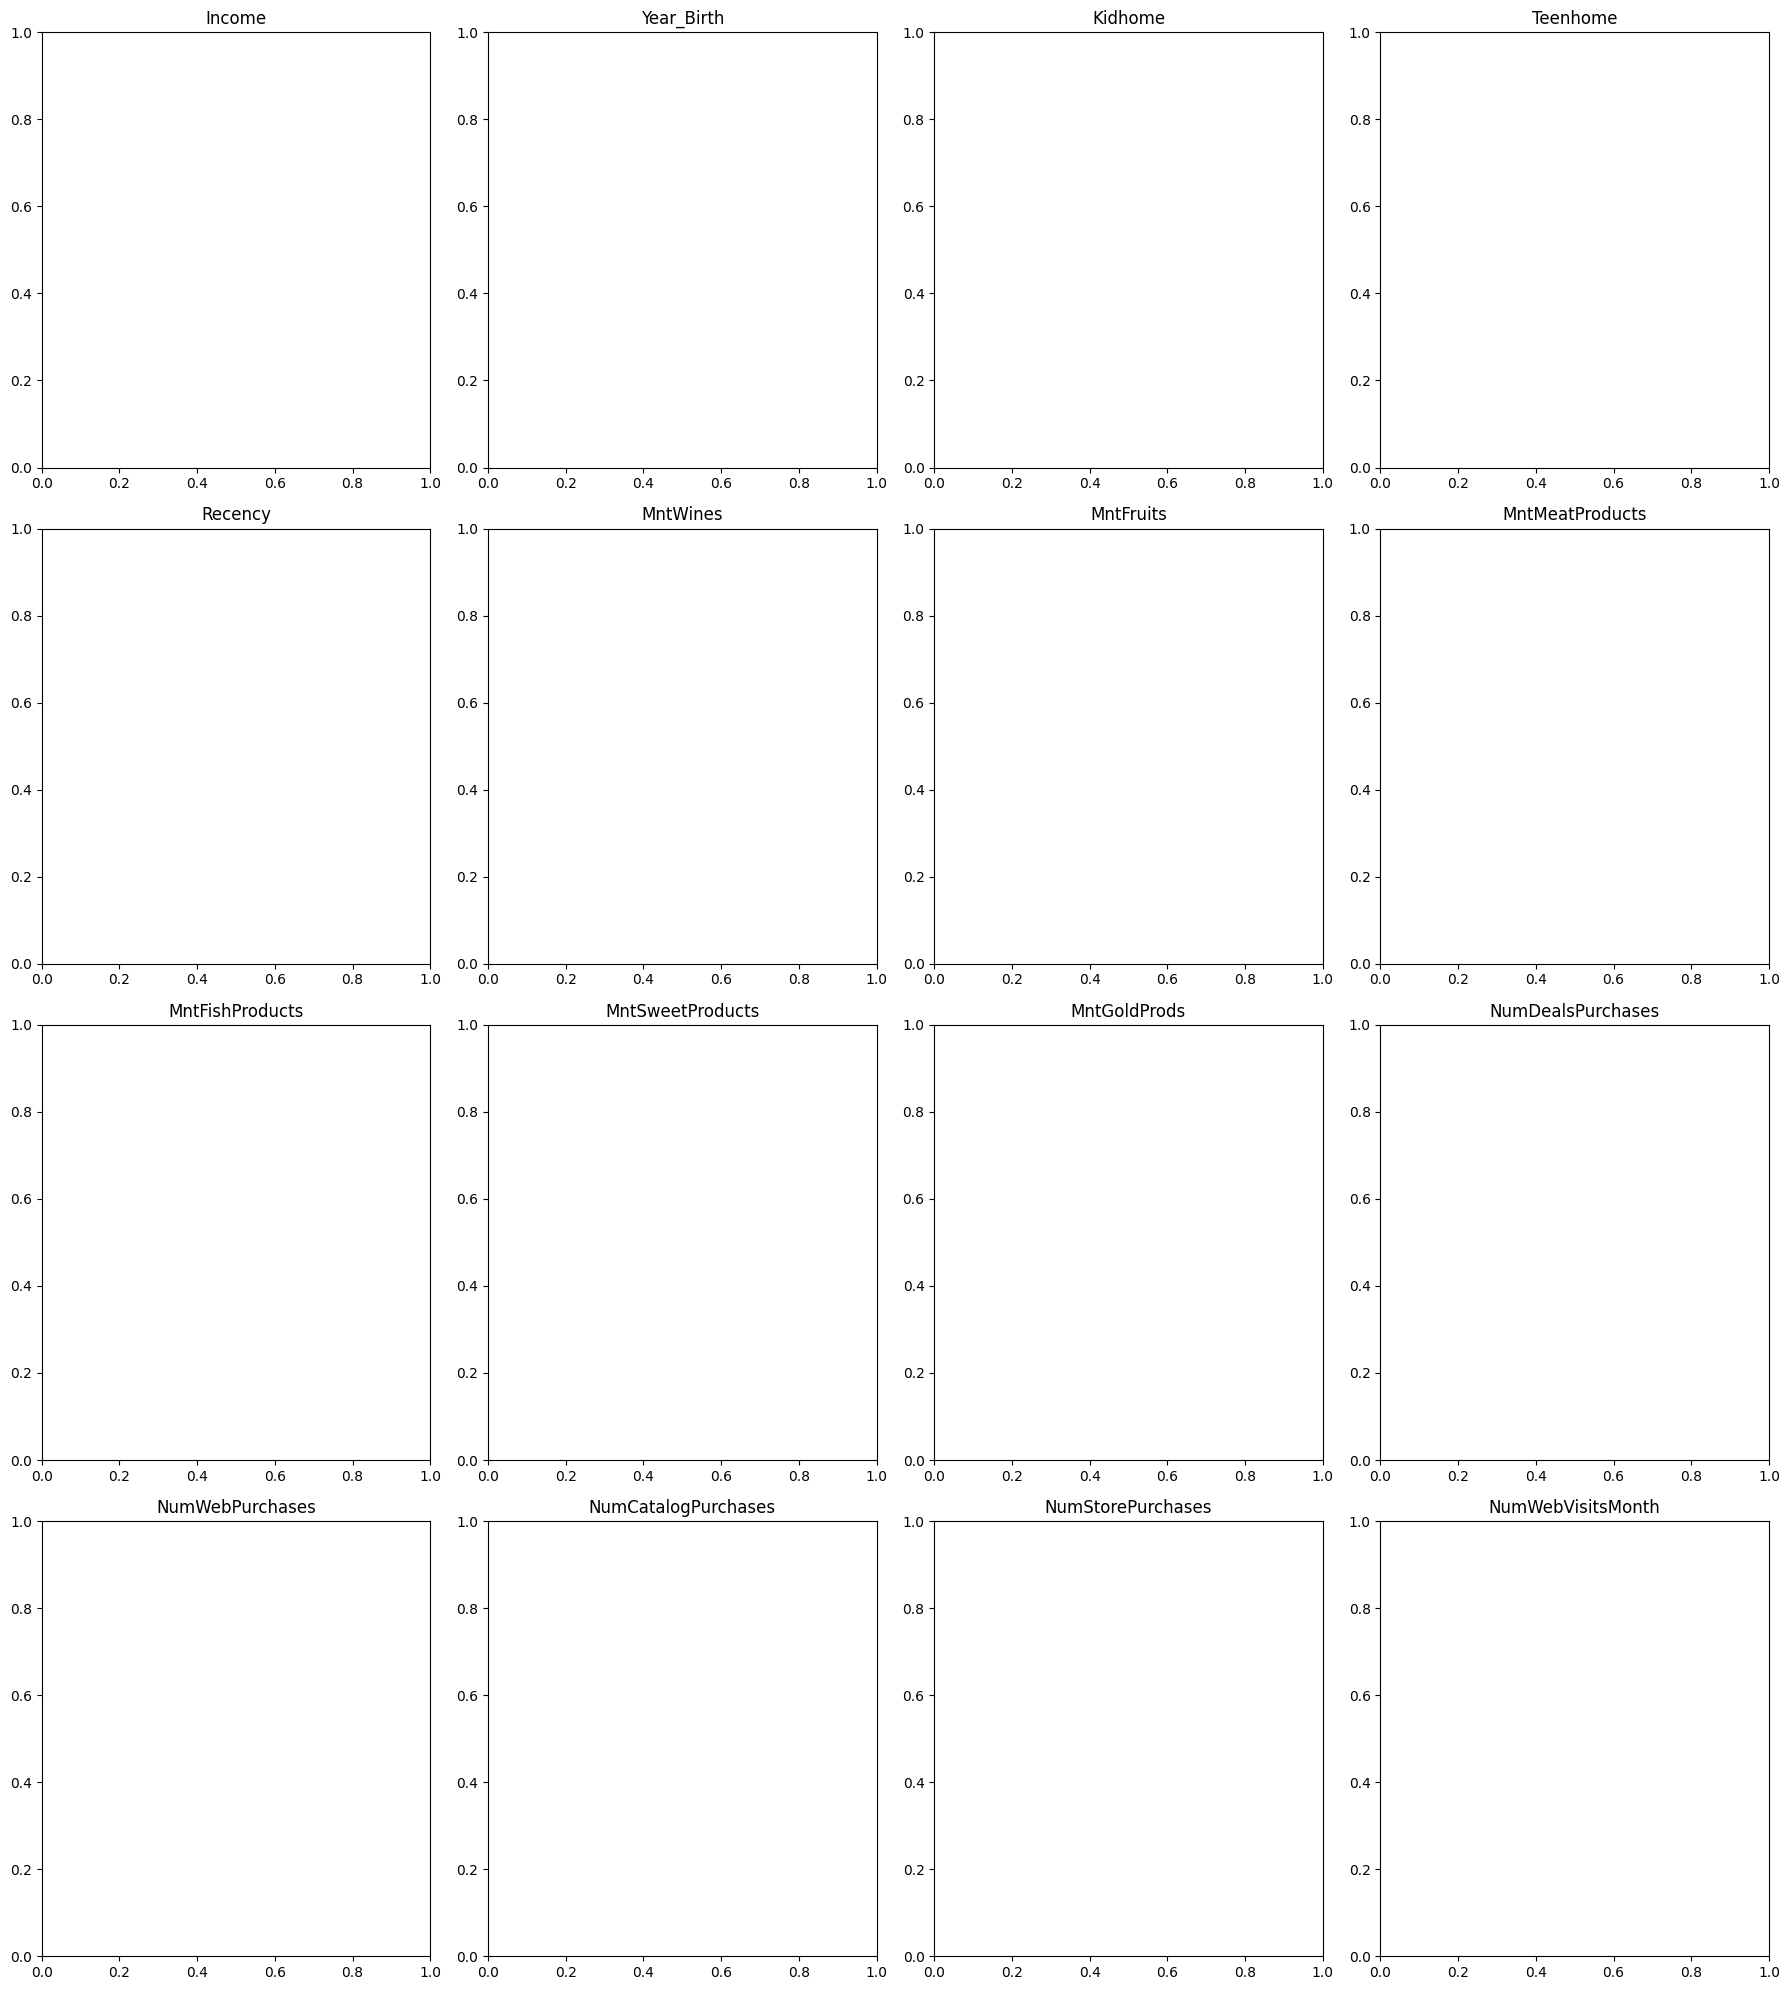

In [31]:
# Outliers Detection
num_vars = [
'Income','Year_Birth', 'Kidhome', 'Teenhome', 'Recency',
'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
'NumWebVisitsMonth'
]

# Set figure size and layout
plt.figure(figsize=(18, 20))

# Loop and plot
for i, col in enumerate(num_vars, 1):
    plt.subplot(4, 4, i)
   # sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.xlabel("")  # Optional: remove x-axis label for cleaner look

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and it has an 'Income' column
# For example:
data = {'Income': [20000, 22000, 25000, 28000, 30000, 32000, 35000, 40000, 45000, 100000, 5000, 120000]}
df = pd.DataFrame(data)

# 1. Calculate Q1 and Q3 from the SAME DataFrame 'df'
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)


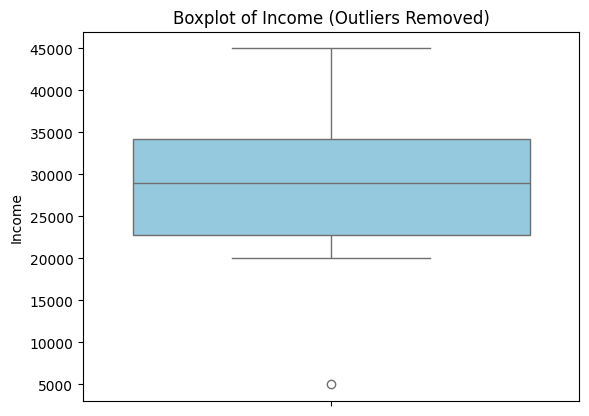

In [15]:
# 2. Calculate IQR
IQR = Q3 - Q1

# 3. Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the DataFrame 'df' to remove outliers
# Both conditions should refer to df['Income']
# It's also good practice to assign to a new DataFrame to keep the original if needed.
df_filtered = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]

# 5. Create a boxplot of the 'Income' from the FILTERED DataFrame
sns.boxplot(y=df_filtered['Income'], color='skyblue')
plt.title('Boxplot of Income (Outliers Removed)')
plt.ylabel('Income')
plt.show() # Add this to display the plot

# You can also compare with the original data's boxplot:
# plt.figure() # Create a new figure for the second plot
# sns.boxplot(y=df['Income'], color='lightcoral')
# plt.title('Boxplot of Income (Original)')
# plt.ylabel('Income')
# plt.show()

In [21]:
from datetime import date

# creating the date object of today's date
todays_date = date.today()

# printing todays date
print("Current date: ", todays_date)


Current date:  2025-05-30


In [24]:
import pandas as pd
from datetime import datetime, date

# Creating a list of date of birth
dob = {'DOB': ['13/05/1986', '12/12/2018', '23/04/2006','23/04/2016','23/04/2008'],
       'Education': ['Graduation','Masters','PhD','Graduation','Masters'],
       'Marital_Status': ['Single','Divorced','Married','Single','Masters'],
       'Total_Accepted': [0,1,2,3,4]

       }

# Creating dataframe
df = pd.DataFrame(data = dob)

# This function converts given date to age
def age(born):
    born = datetime.strptime(born, "%d/%m/%Y").date()
    today = date.today()
    return today.year - born.year - ((today.month,
                                      today.day) < (born.month,
                                                    born.day))

df['Age'] = df['DOB'].apply(age)

display(df)

,DOB,Education,Marital_Status,Total_Accepted,Age
0,13/05/1986,Graduation,Single,0,39
1,12/12/2018,Masters,Divorced,1,6
2,23/04/2006,PhD,Married,2,19
3,23/04/2016,Graduation,Single,3,9
4,23/04/2008,Masters,Masters,4,17


In [11]:
df['Education'].unique()

array(['Graduation', 'Masters', 'PhD'], dtype=object)

In [12]:
def eductation_level(education):
    if education in ['Graduation', 'PhD', 'Master'] :
        return 'High'
    elif education in ['Basic'] :
        return 'Middle'
    else :
        return 'Low'

df['Education_level'] = df['Education'].apply(eductation_level)

In [15]:
df['Marital_Status'].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

In [16]:
def living_status (martial_stat):
    if martial_stat in ['Alone','YOLO','Absurd','Single'] :
        return 'Living Alone'
    else:
        return 'Living with others'
df['Living_Status'] = df['Marital_Status'].apply(living_status)


In [17]:
df['Living_Status'].value_counts()

,count
Living_Status,
Living with others,2
Living Alone,1


In [18]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Single,1
Divorced,1
Married,1


In [48]:
import pandas as pd

data= { 'Response':[0,0,1,0,0]}

df = pd.DataFrame(data)

print(df['Response'].value_counts() )





Response
0    4
1    1
Name: count, dtype: int64


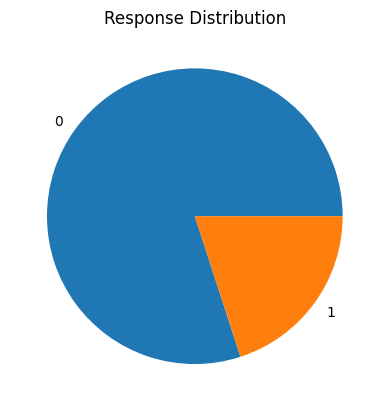

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame and 'Response' is the column you want to use
# Example DataFrame (replace with your actual DataFrame)
data = {'Response': [0,0,0,1,0]}
df = pd.DataFrame(data)

# Count the occurrences of each response
response_counts = df['Response'].value_counts()

# Create the pie chart with labels from the index
plt.pie(response_counts, labels=response_counts.index)
plt.title('Response Distribution') # Add a title to the chart
plt.show()

In [27]:
import seaborn as sns

<Axes: >

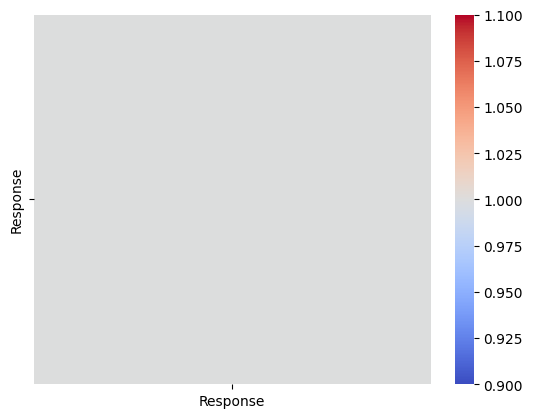

In [28]:
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')

In [31]:
import pandas as pd

In [36]:
import pandas as pd

data = {'Marital_Status': ['Single', 'Married', 'Divorced', 'Single', 'Together']}
df = pd.DataFrame(data)
print(df.value_counts())

Marital_Status
Single            2
Divorced          1
Married           1
Together          1
Name: count, dtype: int64


<ipython-input-37-284b9e1e396b>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df , y = 'Marital_Status',palette='YlOrRd' )


<Axes: xlabel='count', ylabel='Marital_Status'>

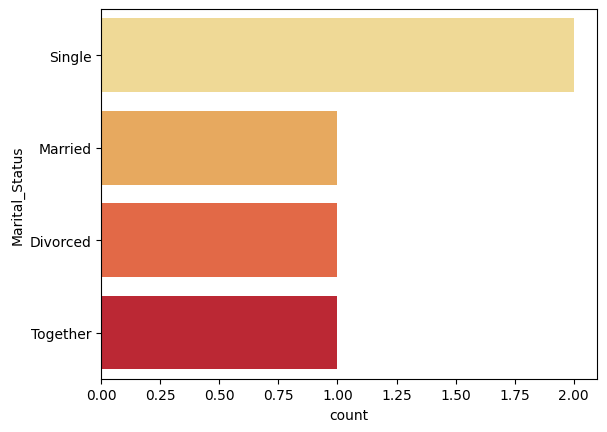

In [37]:
sns.countplot(df , y = 'Marital_Status',palette='YlOrRd' )

In [39]:
import seaborn as sns

<ipython-input-41-1b1c20905e20>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Marital_Status', palette='BuGn', width=0.5)


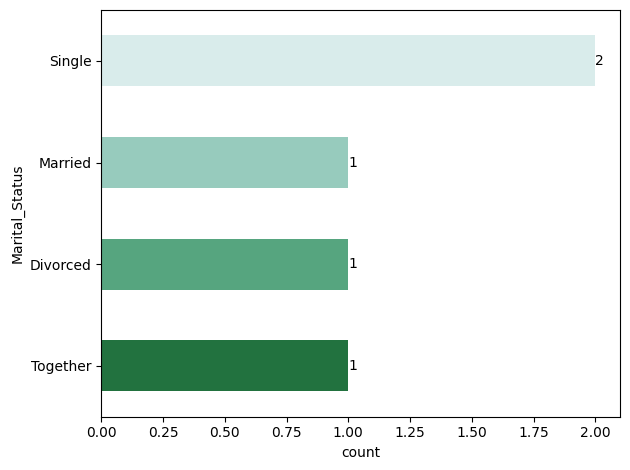

In [41]:
ax = sns.countplot(data=df, y='Marital_Status', palette='BuGn', width=0.5)

# Add count labels
for bar in ax.containers:
    ax.bar_label(bar, label_type='edge')

plt.tight_layout()
plt.show()